<a href="https://colab.research.google.com/github/danielgatto23/MLOP/blob/main/Churn_educacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Início do Programa


Projeto: Modelo Preditivo para calcular Churn no ensino superior no semestre atual
# Autor: Daniel A Gato
Data : 26/07/2025
Versão 1.0
Linguagem: Python
Fonte: Dados Fictícios Simulados
Nota: Case com fins de teste técnico, com limitação de ambiente e variáveis simulados. Para um insigth real é necessário reproduzir esse conceito em ambiente controlado, com dados reais anonimizados e com ampla expansão da técnica abordada, para uma leitura adequada dos resultados obtidos a partir da Modelagem de Machine Learning.

# 0.0 Importar bibliotecas necessárias para o Projeto.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

# 1.0 Importar o Dataset - Procedimento Manual

In [ ]:
#Dataset fictício construído de forma simplificada, com objetivos acadêmicos.
É necessário conduzir um plano estratégico para que sejam catalogadas as principais variáveis que compoem o perfil do aluno, para que possa ser compilado um Book Store de variáveis.
As variáveis podem ser categóricas, numéricas, variáveis de data, podendo ser classificadas conforme sua descrição e categorização natural ou coordenada.
Para que seja um modelo preditivo de classificação, é necessário que a variável target seja binária e que as demais variáveis apresentem suas categorias no tempo em que o modelo pretende prever.
Desta forma, todo o dataset corresponde a variações no tempo na base de estudo e teste, onde poderá no futuro prever qual a probabilidade daquele evento ocorrer, com base no perfil do aluno.
Tal ação é essencial para conduzir uma ação preventiva de gestão de experiência do cliente, visando aumentar seu engajamento, manutenção de faturamento e alongamento da rentabilidade do aluno.

# 1.1 - Construção de Book Store para avaliação das variáveis relacionadas com o evento

In [ ]:
#essa fase não será aplicada no presente exercício
Nota: Dataset simulado para fins de teste técnico. Para fins reais, seguir o planejamento estratégico de desenvolvimento de modelo conforme metodologia apresentada no Canva do modelo.

In [ ]:
# 1.2 importar  arquivos do desktop

from google.colab import files
uploaded = files.upload()


Saving input_ensino_churn.csv to input_ensino_churn.csv


In [ ]:
# Geração de Book store simulado para fins didáticos

# 1.2 validação cabeçalho

In [ ]:
# Leitura do arquivo CSV corrigido
df = pd.read_csv('input_ensino_churn.csv', encoding='latin-1', sep=',')

# Exibição das 10 primeiras linhas
display(df.head(10))

,Média global,Percentual de reprovações,Reprovação por falta,Frequência média,Quantidade de trancamentos,Total de créditos cursados,Disciplinas atrasadas,Tipo de ingresso,Modalidade do curso,Turno do curso,...,Tempo de deslocamento,Situação profissional,Renda familiar estimada,Tem filhos?,Mudança de endereço recente,Solicitação de cancelamento iniciada,Solicitação de trancamento,Participação em pesquisa de evasão,Faltas em provas,Churn
0,70,54,3,86,2,44,5,Transferência,Presencial,Noturno,...,97,Estagiário,295055,Não,Não,Não,Não,Sim,1,0
1,636,43,3,66,0,97,4,Transferência,EAD,Noturno,...,76,Autônomo,372029,Não,Não,Não,Não,Não,1,1
2,715,48,2,72,2,118,1,ENEM,EAD,Noturno,...,35,Estagiário,734512,Sim,Não,Não,Não,Não,2,1
3,802,39,1,75,0,135,2,ENEM,Presencial,Matutino,...,45,Empregado,699088,Sim,Não,Não,Não,Sim,3,0
4,627,10,4,78,2,67,2,ENEM,EAD,Integral,...,30,Desempregado,461212,Não,Não,Não,Sim,Sim,1,0
5,627,2,4,82,2,29,4,ENEM,EAD,Matutino,...,86,Empregado,266674,Sim,Sim,Não,Não,Não,2,0
6,808,58,3,76,0,118,1,Outros,Presencial,Matutino,...,61,Estagiário,235229,Não,Não,Sim,Não,Não,1,0
7,727,5,1,74,0,30,0,ENEM,Presencial,Integral,...,20,Desempregado,767861,Não,Não,Não,Não,Não,3,0
8,603,8,2,59,2,104,0,Outros,Presencial,Noturno,...,17,Desempregado,241902,Não,Não,Não,Não,Não,1,0
9,704,5,1,96,1,154,0,Vestibular,EAD,Noturno,...,66,Autônomo,665718,Sim,Não,Não,Não,Não,3,0


# 2.1 Início do EDA

In [ ]:
# 2.1.1 Descrição das variáveis selecionadas
df.describe()

,Média global,Percentual de reprovações,Reprovação por falta,Frequência média,Quantidade de trancamentos,Total de créditos cursados,Disciplinas atrasadas,Atraso em mensalidades,% parcelas em dia,Valor da mensalidade,...,Atendimentos pedagógicos,Solicitações de tutoria,Avaliação da instituição/curso,Reclamações registradas,Idade,Distância até campus/polo,Tempo de deslocamento,Renda familiar estimada,Faltas em provas,Churn
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,596.732000,28.631000,2.038000,74.946000,1.030000,89.720000,2.461000,60.018000,49.896000,85582.599000,...,0.960000,1.481000,3.117000,1.527000,38.183000,2337.893000,63.61100,409273.793000,1.559000,0.379000
std,195.527039,17.412295,1.411577,14.576198,0.817171,39.901425,1.689181,34.734337,29.126715,39153.908582,...,0.831319,1.108543,1.398308,1.093832,12.438337,1511.238481,31.91649,224434.522336,1.111645,0.485381
min,38.000000,0.000000,0.000000,50.000000,0.000000,20.000000,0.000000,0.000000,0.000000,4010.000000,...,0.000000,0.000000,1.000000,0.000000,17.000000,6.000000,10.00000,10832.000000,0.000000,0.000000
25%,561.750000,13.000000,1.000000,62.000000,0.000000,54.000000,1.000000,30.000000,24.000000,58650.000000,...,0.000000,0.000000,2.000000,1.000000,27.750000,963.000000,36.00000,231783.750000,1.000000,0.000000
50%,642.000000,28.000000,2.000000,75.000000,1.000000,92.500000,3.000000,61.000000,51.000000,88584.500000,...,1.000000,1.500000,3.000000,2.000000,38.000000,2306.000000,64.00000,410748.500000,2.000000,0.000000
75%,711.000000,44.000000,3.000000,88.000000,2.000000,124.250000,4.000000,90.000000,75.000000,118683.500000,...,2.000000,2.000000,4.000000,2.000000,49.000000,3664.000000,91.00000,596005.500000,3.000000,1.000000
max,958.000000,59.000000,4.000000,99.000000,2.000000,159.000000,5.000000,119.000000,100.000000,149946.000000,...,2.000000,3.000000,5.000000,3.000000,59.000000,4999.000000,119.00000,798869.000000,3.000000,1.000000


In [ ]:
# 2.1.2 Descrição das variáveis selecionadas por tipo
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 43 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Média global                          1000 non-null   int64 
 1   Percentual de reprovações             1000 non-null   int64 
 2   Reprovação por falta                  1000 non-null   int64 
 3   Frequência média                      1000 non-null   int64 
 4   Quantidade de trancamentos            1000 non-null   int64 
 5   Total de créditos cursados            1000 non-null   int64 
 6   Disciplinas atrasadas                 1000 non-null   int64 
 7   Tipo de ingresso                      1000 non-null   object
 8   Modalidade do curso                   1000 non-null   object
 9   Turno do curso                        1000 non-null   object
 10  Atraso em mensalidades                1000 non-null   int64 
 11  % parcelas em dia              

In [ ]:
# 2.1.3 Descrição das variáveis selecionadas - Validação de Nulos
df.isna().sum()

,0
Média global,0
Percentual de reprovações,0
Reprovação por falta,0
Frequência média,0
Quantidade de trancamentos,0
Total de créditos cursados,0
Disciplinas atrasadas,0
Tipo de ingresso,0
Modalidade do curso,0
Turno do curso,0


In [ ]:
# 2.1.4 Descrição das variáveis selecionadas - validação de Duplicadas
Sumdupli=df.duplicated().sum()
print("Number of duplicate data:", Sumdupli)

Number of duplicate data: 0


In [ ]:
# 2.1.5 Descrição das variáveis selecionadas - Shape da tabela
row,column=df.shape
print(f"Sum of Row: {row}")
print(f"Sum of Columns: {column}")

Sum of Row: 1000
Sum of Columns: 43


In [ ]:
# 2.1.6 Descrição das variáveis selecionadas - Volume do Evento Churn
df['Churn'].value_counts()

,count
Churn,
0,621
1,379


In [ ]:
# 2.1.6 Descrição das variáveis selecionadas - Volume do Evento Trancamento
df['Solicitação de trancamento'].value_counts()

,count
Solicitação de trancamento,
Não,846
Sim,154


In [ ]:
# 2.1.7 Descrição das variáveis selecionadas - Volume do Evento Trancamento e Churn
# Filter the DataFrame for 'Solicitação de trancamento' equal to 'Sim' and 'Churn' equal to 1
churned_lock_requests = df[(df['Solicitação de trancamento'] == 'Sim') & (df['Churn'] == 1)]

# Count the number of rows in the filtered DataFrame
count_churned_lock_requests = len(churned_lock_requests)

# Print the count
print(f"Number of students with 'Solicitação de trancamento' = 'Sim' and Churn = 1: {count_churned_lock_requests}")

Number of students with 'Solicitação de trancamento' = 'Sim' and Churn = 1: 49


In [ ]:
# 2.1.8 Descrição das variáveis selecionadas - Volume do Evento Trancamento
df['Solicitação de cancelamento iniciada'].value_counts()

,count
Solicitação de cancelamento iniciada,
Não,902
Sim,98


In [ ]:
# 2.1.9 Descrição das variáveis selecionadas - Volume do Cancelamento  e Churn
churned_cancel_requests = df[(df['Solicitação de cancelamento iniciada'] == 'Sim') & (df['Churn'] == 1)]
# Count the number of rows in the filtered DataFrame
count_churned_cancel_requests = len(churned_cancel_requests )
# Print the count
print(f"Number of students with 'Solicitação de cancelamento iniciada' = 'Sim' and Churn = 1: {count_churned_cancel_requests}")

Number of students with 'Solicitação de cancelamento iniciada' = 'Sim' and Churn = 1: 37


In [ ]:
# 2.1.10 Descrição das variáveis selecionadas que viraram churn
raiox_churn = df[df['Churn'] == 1]
# Display descriptive statistics for students who churned
display(raiox_churn.describe())

,Média global,Percentual de reprovações,Reprovação por falta,Frequência média,Quantidade de trancamentos,Total de créditos cursados,Disciplinas atrasadas,Atraso em mensalidades,% parcelas em dia,Valor da mensalidade,...,Atendimentos pedagógicos,Solicitações de tutoria,Avaliação da instituição/curso,Reclamações registradas,Idade,Distância até campus/polo,Tempo de deslocamento,Renda familiar estimada,Faltas em provas,Churn
count,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,...,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.0
mean,594.163588,29.514512,2.039578,67.145119,1.005277,87.633245,3.266491,60.440633,32.915567,83296.087071,...,0.947230,1.443272,3.134565,1.493404,38.013193,2323.298153,63.680739,419815.868074,1.546174,1.0
std,195.212812,17.020737,1.410848,13.518459,0.809973,39.158206,1.642753,34.541341,24.971481,41003.298457,...,0.830861,1.078322,1.431077,1.096813,12.453823,1491.394118,31.993070,218258.325528,1.083720,0.0
min,38.000000,0.000000,0.000000,50.000000,0.000000,20.000000,0.000000,0.000000,0.000000,4010.000000,...,0.000000,0.000000,1.000000,0.000000,17.000000,27.000000,10.000000,10832.000000,0.000000,1.0
25%,558.000000,14.000000,1.000000,56.000000,0.000000,51.000000,2.000000,32.500000,13.500000,54108.000000,...,0.000000,1.000000,2.000000,1.000000,28.000000,968.500000,36.000000,249178.500000,1.000000,1.0
50%,641.000000,31.000000,2.000000,65.000000,1.000000,89.000000,4.000000,63.000000,27.000000,84261.000000,...,1.000000,1.000000,3.000000,2.000000,38.000000,2314.000000,62.000000,422069.000000,2.000000,1.0
75%,710.500000,44.000000,3.000000,74.500000,2.000000,118.000000,5.000000,92.000000,45.500000,116726.000000,...,2.000000,2.000000,4.000000,2.000000,49.000000,3671.000000,91.000000,601246.500000,2.000000,1.0
max,906.000000,59.000000,4.000000,99.000000,2.000000,159.000000,5.000000,118.000000,99.000000,149946.000000,...,2.000000,3.000000,5.000000,3.000000,59.000000,4995.000000,119.000000,798691.000000,3.000000,1.0


In [ ]:
# 2.1.11 Descrição das variáveis selecionadas que viraram churn

# Filter the DataFrame to include only students who churned
churned_students = df[df['Churn'] == 0]

# Create a histogram of 'Disciplinas atrasadas' for churned students
px.histogram(churned_students, x='Disciplinas atrasadas', color_discrete_sequence=['lightblue'],
             title='Distribuição de Disciplinas Atrasadas para Alunos sem Churn')

In [ ]:
# 2.1.12 Descrição das variáveis selecionadas que viraram churn
# Filter the DataFrame to include only students who churned
churned_students = df[df['Churn'] == 1]

# Create a histogram of 'Disciplinas atrasadas' for churned students
px.histogram(churned_students, x='Disciplinas atrasadas', color_discrete_sequence=['lightblue'],
             title='Distribuição de Disciplinas Atrasadas para Alunos com Churn')

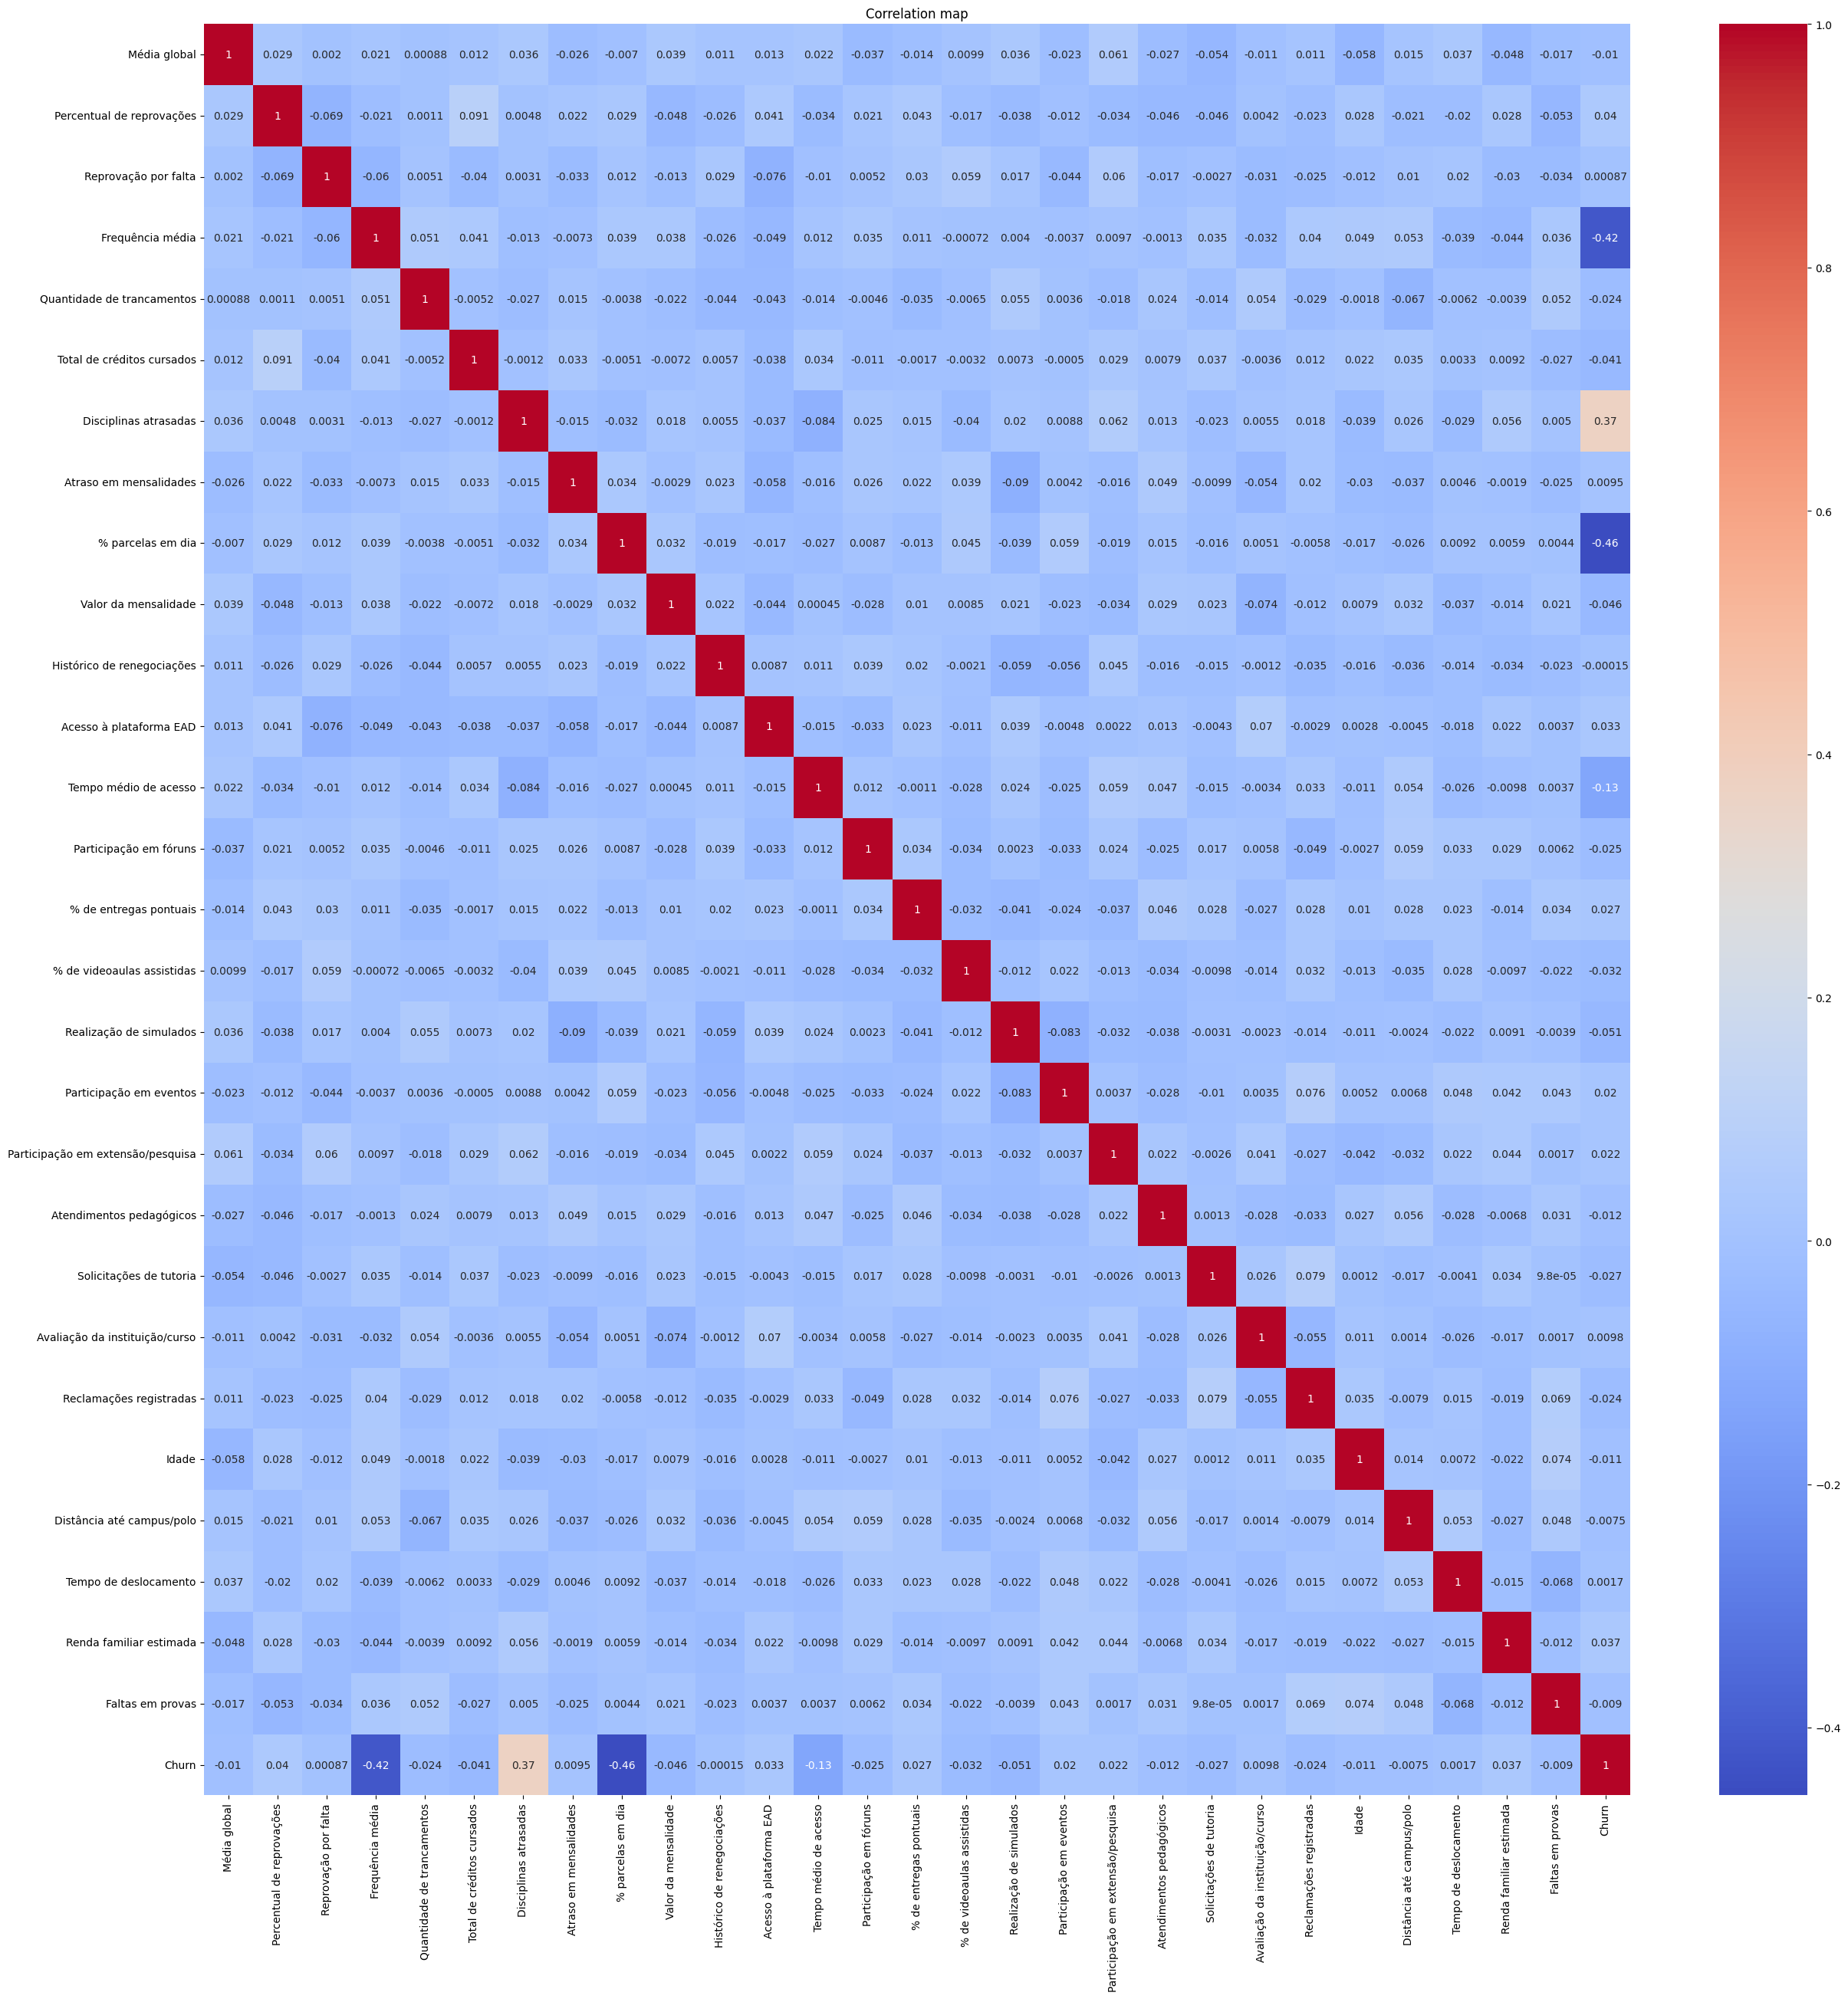

In [ ]:
# 2.1.13 Matriz de Correlação das variáveis com o target

plt.figure(figsize=(30, 30))
# Select only numeric columns before calculating correlation
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation map')
plt.show()




In [ ]:
# 2.1.14 Matriz de Correlação das variáveis com o target
# Calculate correlations with the 'Churn' column
correlations_with_churn = df.select_dtypes(include=np.number).corr()['Churn'].drop('Churn')

# Sort correlations by absolute value in descending order
sorted_correlations = correlations_with_churn.abs().sort_values(ascending=False)

# Display the list of variables with their correlations
print("Variables with highest correlation with Churn:")
display(sorted_correlations)

Variables with highest correlation with Churn:


,Churn
% parcelas em dia,0.455668
Frequência média,0.418303
Disciplinas atrasadas,0.372714
Tempo médio de acesso,0.133364
Realização de simulados,0.051267
Valor da mensalidade,0.045645
Total de créditos cursados,0.040877
Percentual de reprovações,0.039660
Renda familiar estimada,0.036714
Acesso à plataforma EAD,0.032965


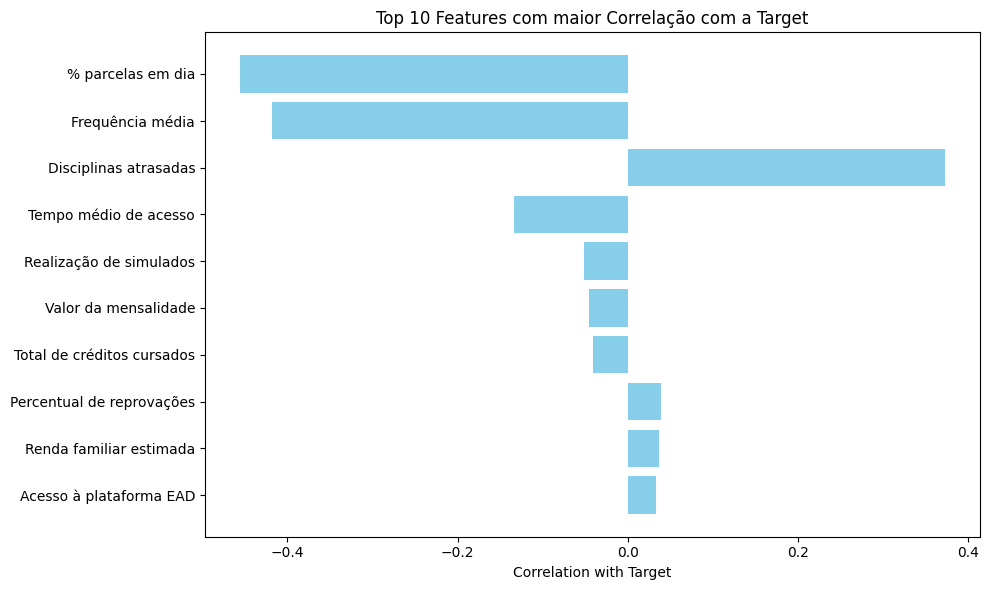

In [ ]:
# 2.1.15 Top variáveis com correlação com a target
correlation = df.select_dtypes(include=np.number).corr()['Churn'].drop('Churn')
top_10_features = correlation.abs().nlargest(10).index
top_10_corr = correlation[top_10_features]

plt.figure(figsize=(10, 6))
plt.barh(top_10_features, top_10_corr, color='skyblue')
plt.xlabel('Correlation with Target')
plt.title('Top 10 Features com maior Correlação com a Target')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

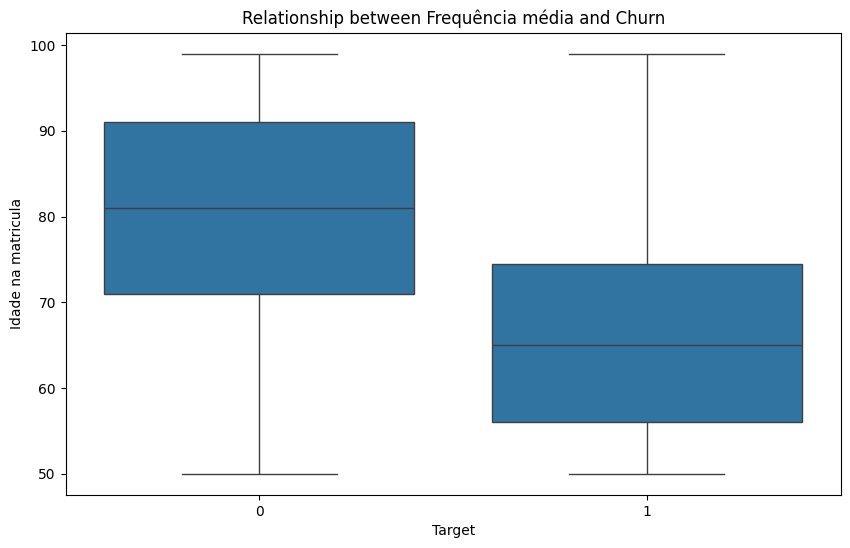

In [ ]:
# 2.1.16 Top variáveis com correlação com a target


plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y = 'Frequência média', data = df)
plt.xlabel('Target')
plt.ylabel('Idade na matricula')
plt.title('Relationship between Frequência média and Churn')
plt.show()

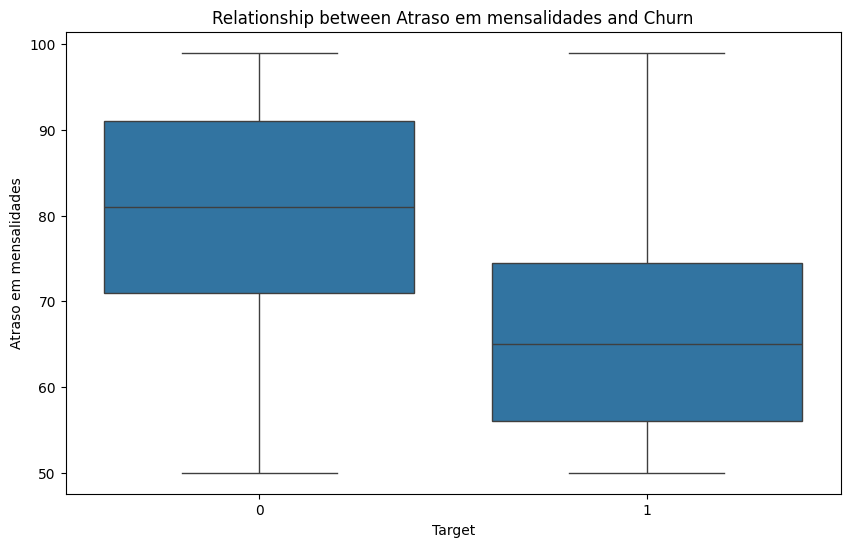

In [ ]:
# 2.1.16 Top variáveis com correlação com a target


plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y = 'Frequência média', data = df)
plt.xlabel('Target')
plt.ylabel('Atraso em mensalidades')
plt.title('Relationship between Atraso em mensalidades and Churn')
plt.show()

# 3.0 Modelagem


Model Build

Split the Data Into Data Train and Data Test

Split data after feature selection

In [ ]:
# 3.1  Separar em treino e teste aleatoriamente

X=df[[ '% parcelas em dia','Frequência média','Disciplinas atrasadas','Tempo médio de acesso','Realização de simulados','Valor da mensalidade','Total de créditos cursados','Percentual de reprovações','Renda familiar estimada','Acesso à plataforma EAD']]
y=df['Churn']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)
print(f"Data Training shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Data Testing shape: X_test {X_test.shape}, y_test: {y_test.shape}")

Data Training shape: X_train (800, 10), y_train (800,)
Data Testing shape: X_test (200, 10), y_test: (200,)


3.1 Construção do Modelo

In [ ]:
# 3.2  Calcula os KPIs de acordo com o modelo selecionado
Dt=DecisionTreeClassifier().fit(X_train_encoded, y_train)
Rf=RandomForestClassifier().fit(X_train_encoded, y_train)
svm=SVC().fit(X_train_encoded, y_train)
Lr=LogisticRegression(solver='liblinear',max_iter=10000, verbose=1).fit(X_train_encoded, y_train)

[LibLinear]

In [ ]:
def evaluate_model(model,X_test, y_test):
    y_pred=model.predict(X_test)

    results={
        'Accuracy':accuracy_score(y_pred, y_test),
        'Precision':precision_score(y_pred, y_test),
        'Recall':recall_score(y_pred, y_test),
        'F1 Score': f1_score(y_pred,y_test)
    }
    return results

In [ ]:
# 3.3  Calcula os KPIs de acordo com o modelo selecionado
results={
    'Decision Tree (After Feature Selection)':evaluate_model(Dt, X_test_encoded, y_test),
    'Random Forest (After Feature Selection)':evaluate_model(Rf, X_test_encoded, y_test),
    'SVM (After Feature Selection)':evaluate_model(svm, X_test_encoded, y_test),
    'Logistic Regression (After Feature Selection)':evaluate_model(Lr, X_test_encoded, y_test)
}

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.



In [ ]:
# Initialize an empty DataFrame to store model evaluation results
summary_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

4.0 Avaliação do Modelo

In [ ]:
new_row=[]
for model_name, metrics in results.items():
    new_row.append({
        'Model':model_name,
        'Accuracy':metrics['Accuracy'],
        'Precision':metrics['Precision'],
        'Recall':metrics['Recall'],
        'F1 Score':metrics['F1 Score']
    })

new_df=pd.DataFrame(new_row)
summary_df=pd.concat([summary_df,new_df],ignore_index=True)
display(summary_df.head(8))

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree (After Feature Selection),0.985,0.972603,0.986111,0.979310
1,Random Forest (After Feature Selection),0.965,0.904110,1.000000,0.949640
2,SVM (After Feature Selection),0.635,0.000000,0.000000,0.000000
3,Logistic Regression (After Feature Selection),0.805,0.671233,0.765625,0.715328
4,Decision Tree (After Feature Selection),0.985,0.972603,0.986111,0.979310
5,Random Forest (After Feature Selection),0.965,0.904110,1.000000,0.949640
6,SVM (After Feature Selection),0.635,0.000000,0.000000,0.000000
7,Logistic Regression (After Feature Selection),0.805,0.671233,0.765625,0.715328


5.0 Validação do Modelo

In [ ]:
#essa fase não será aplicada no presente exercício

6.0 Scoragem do Churn por aluno

In [ ]:
#essa fase não será aplicada no presente exercício

7.0 Deploy e Monitoramento do Modelo

In [ ]:
#essa fase não será aplicada no presente exercício

8.0 Conclusão

In [ ]:
#Desenvolvimento do modelo se demonstrou viável, com resultados satisfatórios na comparação com outras técnicas de classificação, utilizando modelos de machine learning.
- A metodologia utilizada foi desenvolvida de forma simplificada, visando apresentar algumas técnicas de modelagem estatística, porém, seus resultados não devem ser interpretados como realidade.
- ações Recomendadas:
    - Aspecto Financeiro: Ofertar mecanismos financeiros para negociações e alongamento de prado de parcelas em atraso com período superior à 6 meses;
    - Engajamento: Ofertar programa de atividades extra-curriculares e/ou em modalidade diferente do que o aluno já pratica, para recuperação de matérias perdidas, quando essa reprovação esteja acima da média ou comprometa a continuidade do curso pelo aluno.
    - Atraso no curso: Viabilizar um plano de recuperação de disciplinas em atraso, ofertando um roteiro de desenvolvimento acadêmico que poderá ser ofertado na mesma ou em outra modalidade que o aluno cursa, conjuntamente com outras atividades complementarees.
    - Projeto Integrador: Promover disciplina integradora como um projeto de recuperação de disciplinas perdidas ou projeto de conclusão de curso, visando aplicar uma metodologia ágil para desenvolvimento de projetos (Kanban / Canvas), onde o aluno desenvolve um projeto temático que pode ser na matéria específica ou em várias matérias correlacionadas, visando apresentar requisitos mínimos para substituição da matéria em atraso.
    - Bonificação por Engajamento: Oferta de pontuação extra por assiduidade nas aulas, visando promover mecanismos facilitadores para complementar a nota da matéria.
    - Mentoria Personalizada: Viabilizar um plano de desenvolvimento acadêmico e profissional personalizado para o aluno, identificando as principais dores, potenciais e auxiliando na direção de um plano de ação viável de desenvolvimento acadêmico e de carreita.
